In [ ]:
import torch
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset

In [ ]:
DATA_DIR = '/content/drive/MyDrive/ML_assignment'

f = open(f"{DATA_DIR}/train.txt")
train = [float(x) for x in f.read().split()]
f.close()

train = torch.tensor(train).view(-1, 6)
X_train = train[:, :5]
Y_train = train[:, 5].long()

print(X_train.shape, X_train.dtype)
print(Y_train.shape, Y_train.dtype)

torch.Size([6943, 5]) torch.float32
torch.Size([6943]) torch.int64


In [ ]:
DATA_DIR = '/content/drive/MyDrive/ML_assignment'

f = open(f"{DATA_DIR}/validation.txt")
validation = [float(x) for x in f.read().split()]
f.close()

validation = torch.tensor(validation).view(-1, 6)
X_val = validation[:, :5]
Y_val = validation[:, 5].long()
print(X_val.shape, X_val.dtype)
print(Y_val.shape, Y_val.dtype)

torch.Size([400, 5]) torch.float32
torch.Size([400]) torch.int64


In [ ]:
DATA_DIR = '/content/drive/MyDrive/ML_assignment'

f = open(f"{DATA_DIR}/test.txt")
test = [float(x) for x in f.read().split()]
f.close()

test = torch.tensor(test).view(-1, 6)
X_test = test[:, :5]
Y_test = test[:, 5].long()

print(X_test.shape, X_test.dtype)
print(Y_test.shape, Y_test.dtype)

torch.Size([800, 5]) torch.float32
torch.Size([800]) torch.int64


In [ ]:
mu = X_train.mean(0)
sigma = X_train.std(0)

X_train = (X_train - mu) / sigma
X_val = (X_val - mu) / sigma
X_test = (X_test - mu) / sigma

## Logistic regression

In [ ]:
def logreg_inference(w, b, X):
    logits = X @ w + b
    p = torch.sigmoid(logits)
    return p

0 0.6931474208831787
1000 0.15870970487594604
2000 0.11398304998874664
3000 0.09615322947502136
4000 0.08641713112592697
5000 0.08024900406599045
6000 0.07598406821489334
7000 0.0728592798113823
8000 0.07047330588102341
9000 0.06859412789344788


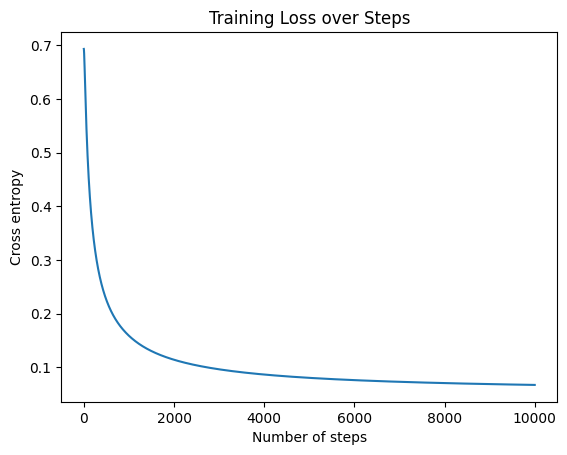

In [ ]:
LR = 0.001
STEPS = 10000

w = torch.zeros(5, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
optimizer = torch.optim.SGD([w, b], lr=LR, momentum=0.9)

losses = []
steps = []

def loss_d(p, Y): # Cross entropy loss function
  l= -Y * torch.log(p) - (1 - Y) * torch.log(1 - p)
  return l.mean()

for step in range(STEPS):
    optimizer.zero_grad()
    p = logreg_inference(w, b, X_train)
    p = p.clamp(0.001, 0.999)
    loss = loss_d(p, Y_train)
    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(step, loss.item())
    losses.append(loss.item())
    steps.append(step)

plt.figure()
plt.plot(steps, losses)
plt.xlabel("Number of steps")
plt.ylabel("Cross entropy")
plt.title("Training Loss over Steps")
plt.savefig('loss_plot.jpg', format='jpg', bbox_inches='tight')
plt.show()

In [ ]:
p = logreg_inference(w, b, X_train)
predictions = (p > 0.5).long()
accuracy = (predictions == Y_train).float().mean()
print("Training accuracy = ", accuracy.item())

Training accuracy =  0.9877574443817139


In [ ]:
predictions = (logreg_inference(w, b, X_test) > 0.5).long()
test_accuracy = (predictions == Y_test).float().mean()
print("Test accuracy = ", test_accuracy.item())

Test accuracy =  0.9912499785423279


In [ ]:
features = ['temperature', 'humidity', 'light', 'co2', 'humidity_ratio']
max_len = max(len(f) for f in features + ['bias'])

# Header
print(f"{'Feature':<{max_len}} | Weight")
print("-" * (max_len + 10))

# Rows
for feat in range(5):
    print(f"{features[feat]:<{max_len}} | {w[feat].item():.4f}")

# Bias
print("-" * (max_len + 10))
print(f"{'bias':<{max_len}} | {b.item():.4f}")

Feature        | Weight
------------------------
temperature    | -0.5231
humidity       | 0.0240
light          | 2.8048
co2            | 1.1943
humidity_ratio | -0.0545
------------------------
bias           | -2.8849


## Multilayer Perceptron

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [ ]:
net_1 = torch.nn.Sequential(
    torch.nn.Linear(5, 2),
    torch.nn.ReLU(),
    torch.nn.Linear(2, 2)
)
net_1.to(DEVICE)

ps = sum(p.numel() for p in net_1.parameters())
print(f"Number of parameters: {ps}")

net_2 = torch.nn.Sequential(
    torch.nn.Linear(5, 4),
    torch.nn.ReLU(),
    torch.nn.Linear(4, 2)
)
net_2.to(DEVICE)

ps = sum(p.numel() for p in net_2.parameters())
print(f"Number of parameters: {ps}")

net_3 = torch.nn.Sequential(
    torch.nn.Linear(5, 2),
    torch.nn.ReLU(),
    torch.nn.Linear(2, 2),
    torch.nn.ReLU(),
    torch.nn.Linear(2, 2)
)
net_3.to(DEVICE)

ps = sum(p.numel() for p in net_3.parameters())
print(f"Number of parameters: {ps}")

nets = [net_1, net_2, net_3]

Number of parameters: 18
Number of parameters: 34
Number of parameters: 24


In [ ]:
BATCH_SIZE = 64

train_dataset = torch.utils.data.TensorDataset(X_train, Y_train)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = torch.utils.data.TensorDataset(X_val, Y_val)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = torch.utils.data.TensorDataset(X_test, Y_test)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
def train(net, LR, EPOCHS, MOMENTUM):
    loss_fun = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=LR, momentum=MOMENTUM)
    steps = 0

    epochs_list = []
    train_accs = []
    test_accs = []

    for epoch in range(EPOCHS):
        net.train()
        for features, labels in train_loader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = net(features)
            loss = loss_fun(logits, labels)
            loss.backward()
            optimizer.step()
            steps += 1
            if steps % 1000 == 0:
                predictions = torch.argmax(logits, dim=1)
                accuracy = (predictions == labels).float().mean()
                print(f"Epoch {epoch} step {steps} loss {loss.item():.4f} acc. {accuracy * 100:.1f}%")

        net.eval()
        with torch.no_grad():
            train_logits = net(X_train.to(DEVICE))
            train_pred = torch.argmax(train_logits, dim=1)
            train_accuracy = (train_pred == Y_train.to(DEVICE)).float().mean().item() * 100

            test_logits = net(X_test.to(DEVICE))
            test_pred = torch.argmax(test_logits, dim=1)
            test_accuracy = (test_pred == Y_test.to(DEVICE)).float().mean().item() * 100

        epochs_list.append(epoch)
        train_accs.append(train_accuracy)
        test_accs.append(test_accuracy)

    return net, epochs_list, train_accs, test_accs

In [ ]:
def train_acc(NET):
    ok = 0
    tot = 0

    for features, labels in train_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = NET(features)
        predictions = torch.argmax(logits, dim=1)
        ok += (predictions == labels).long().sum()
        tot += len(labels)

    accuracy = (ok / tot).item() * 100
    return accuracy

In [ ]:
def val_acc(NET):
    ok = 0
    tot = 0
    for features, labels in val_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = NET(features)
        predictions = torch.argmax(logits, dim=1)
        ok += (predictions == labels).long().sum()
        tot += len(labels)
    accuracy = (ok / tot).item() * 100
    return accuracy

In [ ]:
def test_acc(NET):
    ok = 0
    tot = 0

    for features, labels in test_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = NET(features)
        predictions = torch.argmax(logits, dim=1)
        ok += (predictions == labels).long().sum()
        tot += len(labels)

    accuracy = (ok / tot).item() * 100
    return accuracy

In [ ]:
LR = 0.01
MOMENTUM = 0.9
EPOCHS = 100

trained_nets = []
histories = {}

for i, net in enumerate(nets):
    print(f"\n--- Training net {i+1} ---")
    net, epochs_list, train_accs, test_accs = train(net, LR, EPOCHS, MOMENTUM)
    trained_nets.append(net)
    histories[i] = {
        "epochs": epochs_list,
        "train_acc": train_accs,
        "test_acc": test_accs
    }

nets = trained_nets


--- Training net 1 ---
Epoch 9 step 1000 loss 0.0823 acc. 98.4%
Epoch 18 step 2000 loss 0.0215 acc. 100.0%
Epoch 27 step 3000 loss 0.0080 acc. 100.0%
Epoch 36 step 4000 loss 0.0208 acc. 100.0%
Epoch 45 step 5000 loss 0.0559 acc. 98.4%
Epoch 55 step 6000 loss 0.0175 acc. 100.0%
Epoch 64 step 7000 loss 0.0285 acc. 100.0%
Epoch 73 step 8000 loss 0.0961 acc. 96.9%
Epoch 82 step 9000 loss 0.0355 acc. 100.0%
Epoch 91 step 10000 loss 0.0279 acc. 100.0%

--- Training net 2 ---
Epoch 9 step 1000 loss 0.0173 acc. 100.0%
Epoch 18 step 2000 loss 0.0135 acc. 100.0%
Epoch 27 step 3000 loss 0.0144 acc. 100.0%
Epoch 36 step 4000 loss 0.0715 acc. 98.4%
Epoch 45 step 5000 loss 0.0973 acc. 95.3%
Epoch 55 step 6000 loss 0.0536 acc. 98.4%
Epoch 64 step 7000 loss 0.0114 acc. 100.0%
Epoch 73 step 8000 loss 0.0171 acc. 100.0%
Epoch 82 step 9000 loss 0.0406 acc. 98.4%
Epoch 91 step 10000 loss 0.0954 acc. 96.9%

--- Training net 3 ---
Epoch 9 step 1000 loss 0.0138 acc. 100.0%
Epoch 18 step 2000 loss 0.1001 acc

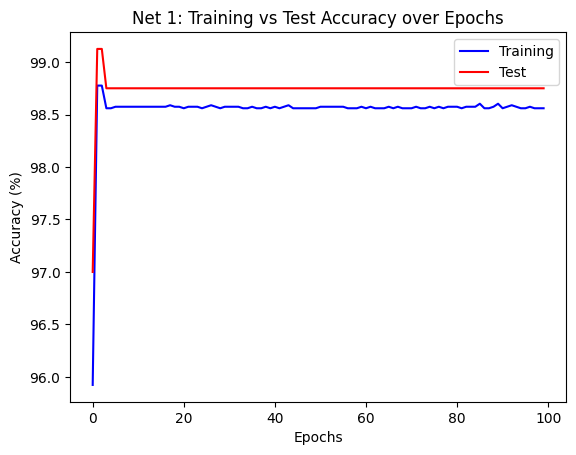

In [ ]:
h = histories[0]

plt.figure()
plt.plot(h["epochs"], h["train_acc"], label="Training", color="blue")
plt.plot(h["epochs"], h["test_acc"], label="Test", color="red")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("Net 1: Training vs Test Accuracy over Epochs")
plt.legend()
#plt.grid(True)
plt.savefig("MLP accuracy.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
results = []

for i, net in enumerate(nets):
    net.eval()
    train_accuracy = train_acc(net)
    validation_accuracy = val_acc(net)
    test_accuracy = test_acc(net)

    results.append({
        "net": i+1,
        "train_acc": train_accuracy,
        "val_acc": validation_accuracy,
        "test_acc": test_accuracy
    })

    print(f"Net {i+1}: train={train_accuracy:.2f}%  val={validation_accuracy:.2f}%  test={test_accuracy:.2f}%")

print("\n--- Summary ---")
print(f"{'Net':<6}{'Train':>10}{'Val':>10}{'Test':>10}")
for r in results:
    print(f"{r['net']:<6}{r['train_acc']:>9.2f}%{r['val_acc']:>9.2f}%{r['test_acc']:>9.2f}%")

Net 1: train=98.56%  val=99.00%  test=98.75%
Net 2: train=98.75%  val=99.00%  test=99.12%
Net 3: train=98.79%  val=99.00%  test=99.12%

--- Summary ---
Net        Train       Val      Test
1         98.56%    99.00%    98.75%
2         98.75%    99.00%    99.12%
3         98.79%    99.00%    99.12%


## Error analysis

In [ ]:
class_names = ["not occupied", "occupied"]

In [ ]:
p_test = logreg_inference(w, b, X_test)
predictions = (p_test > 0.5).long()

codes = Y_test * 2 + predictions
hist = torch.bincount(codes, minlength=2 ** 2)
cm = hist.view(2, 2)

cm_norm = cm / cm.sum(1).unsqueeze(1)  # Normalization

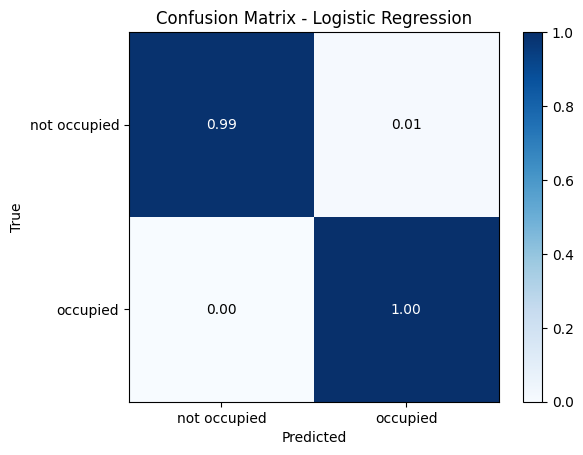

In [ ]:
plt.figure(dpi=100)
plt.imshow(cm_norm, cmap="Blues")
plt.xticks(range(2), class_names)
plt.yticks(range(2), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_norm[i, j].item():.2f}", ha="center", va="center",
                  color="white" if cm_norm[i, j] > 0.5 else "black")
plt.savefig("confusion_matrix_logreg.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
cm = torch.zeros(2, 2, dtype=int)

net_1.eval()
for features, labels in test_loader:
    features = features.to(DEVICE)
    labels = labels.to(DEVICE)
    with torch.no_grad():
        logits = net_1(features)
    predictions = torch.argmax(logits, dim=1)
    codes = labels * 2 + predictions
    hist = torch.bincount(codes.cpu(), minlength=2 ** 2)
    cm += hist.view(2, 2)

cm_norm = cm / cm.sum(1).unsqueeze(1)  # Normalization

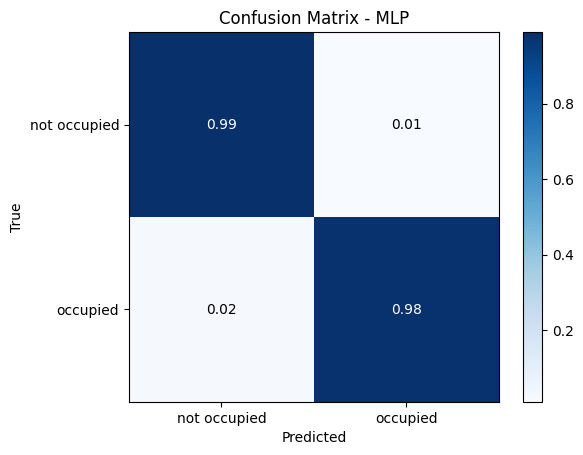

In [ ]:
class_names = ["not occupied", "occupied"]

plt.figure(dpi=100)
plt.imshow(cm_norm, cmap="Blues")
plt.xticks(range(2), class_names)
plt.yticks(range(2), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MLP")
plt.colorbar()
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_norm[i, j].item():.2f}", ha="center", va="center",
                  color="white" if cm_norm[i, j] > 0.5 else "black")
plt.savefig("confusion_matrix_mlp.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
p_test = logreg_inference(w, b, X_test)
predictions = (p_test > 0.5).long()

errors_mask = predictions != Y_test
error_indices = torch.where(errors_mask)[0]

error_confidences = (p_test[error_indices] - 0.5).abs()
sorted_order = error_confidences.argsort(descending=True)

top_indices = error_indices[sorted_order[:10]] # This lines controls the number of samples plotted

features = ['temperature', 'humidity', 'light', 'co2', 'humidity_ratio']
class_names = ["not occupied", "occupied"]

for rank, idx in enumerate(top_indices):
    idx = idx.item()
    print(f"[{rank+1}] Sample {idx}")
    print(f"    True: {class_names[Y_test[idx].item()]}  Predicted: {class_names[predictions[idx].item()]}  p = {p_test[idx].item():.4f}")
    for f_name, f_val in zip(features, X_test[idx]):
        print(f"    {f_name}: {f_val.item():.4f}")
    print()

[1] Sample 433
    True: not occupied  Predicted: occupied  p = 0.9958
    temperature: 2.1941
    humidity: 0.1093
    light: 2.8381
    co2: 1.3234
    humidity_ratio: 0.7890

[2] Sample 745
    True: not occupied  Predicted: occupied  p = 0.9796
    temperature: 2.2268
    humidity: 0.0951
    light: 2.2823
    co2: 1.3084
    humidity_ratio: 0.7838

[3] Sample 393
    True: not occupied  Predicted: occupied  p = 0.9706
    temperature: 2.0072
    humidity: 0.1534
    light: 2.0613
    co2: 1.4131
    humidity_ratio: 0.7766

[4] Sample 49
    True: not occupied  Predicted: occupied  p = 0.8434
    temperature: 1.5777
    humidity: 0.0187
    light: 1.7036
    co2: 0.5378
    humidity_ratio: 0.4907

[5] Sample 376
    True: not occupied  Predicted: occupied  p = 0.7468
    temperature: -0.4435
    humidity: -1.2770
    light: 1.5426
    co2: -0.5309
    humidity_ratio: -1.3392

[6] Sample 655
    True: not occupied  Predicted: occupied  p = 0.7356
    temperature: -0.4189
    humidit

In [ ]:
net_1.eval()
with torch.no_grad():
    logits_test = net_1(X_test.to(DEVICE))
    probs_test = torch.softmax(logits_test, dim=1)
    predictions_mlp = torch.argmax(logits_test, dim=1)

Y_test_device = Y_test.to(DEVICE)
errors_mask_mlp = predictions_mlp != Y_test_device
error_indices_mlp = torch.where(errors_mask_mlp)[0]

error_confidences_mlp = probs_test[error_indices_mlp, predictions_mlp[error_indices_mlp]]
sorted_order_mlp = error_confidences_mlp.argsort(descending=True)

top_indices_mlp = error_indices_mlp[sorted_order_mlp[:10]] # This lines controls the number of samples plotted

for rank, idx in enumerate(top_indices_mlp):
    idx = idx.item()
    print(f"[{rank+1}] Sample {idx}")
    print(f"    True: {class_names[Y_test[idx].item()]}")
    print(f"    Predicted: {class_names[predictions_mlp[idx].item()]}")
    print(f"    p = {probs_test[idx, predictions_mlp[idx]].item():.4f}")
    for f_name, f_val in zip(features, X_test[idx]):
        print(f"    {f_name}: {f_val.item():.4f}")
    print()

[1] Sample 433
    True: not occupied
    Predicted: occupied
    p = 0.9979
    temperature: 2.1941
    humidity: 0.1093
    light: 2.8381
    co2: 1.3234
    humidity_ratio: 0.7890

[2] Sample 745
    True: not occupied
    Predicted: occupied
    p = 0.9803
    temperature: 2.2268
    humidity: 0.0951
    light: 2.2823
    co2: 1.3084
    humidity_ratio: 0.7838

[3] Sample 393
    True: not occupied
    Predicted: occupied
    p = 0.9724
    temperature: 2.0072
    humidity: 0.1534
    light: 2.0613
    co2: 1.4131
    humidity_ratio: 0.7766

[4] Sample 376
    True: not occupied
    Predicted: occupied
    p = 0.8547
    temperature: -0.4435
    humidity: -1.2770
    light: 1.5426
    co2: -0.5309
    humidity_ratio: -1.3392

[5] Sample 655
    True: not occupied
    Predicted: occupied
    p = 0.8419
    temperature: -0.4189
    humidity: -1.2724
    light: 1.5247
    co2: -0.5270
    humidity_ratio: -1.3299

[6] Sample 198
    True: not occupied
    Predicted: occupied
    p = 0.

## Special request

In [ ]:
def precision_recall_at_bias(w, b_offset, X, Y):
    p = logreg_inference(w, b + b_offset, X)
    predictions = (p > 0.5).long()

    tp = ((predictions == 1) & (Y == 1)).sum().item()
    fp = ((predictions == 1) & (Y == 0)).sum().item()
    fn = ((predictions == 0) & (Y == 1)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return precision, recall

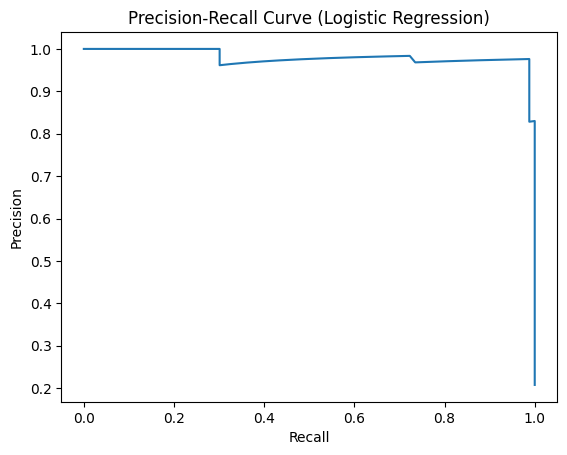

In [ ]:
b_offsets = torch.linspace(-10, 10, 2000)

precisions = []
recalls = []

for offset in b_offsets:
    prec, rec = precision_recall_at_bias(w, offset.item(), X_val, Y_val)
    precisions.append(prec)
    recalls.append(rec)

plt.figure()
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic Regression)")
#plt.grid(True)
plt.savefig("Precision_recall_logistic.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def precision_recall_at_bias_offset(NET, b_offset, X, Y):
    original_bias = NET[-1].bias.data.clone()  # salva il bias originale dell'ultimo layer

    NET[-1].bias.data[1] += b_offset  # sposta solo il bias della classe 1

    NET.eval()
    with torch.no_grad():
        logits = NET(X.to(DEVICE))
        predictions = torch.argmax(logits, dim=1)

    NET[-1].bias.data = original_bias  # ripristina il bias originale

    Y = Y.to(DEVICE)
    tp = ((predictions == 1) & (Y == 1)).sum().item()
    fp = ((predictions == 1) & (Y == 0)).sum().item()
    fn = ((predictions == 0) & (Y == 1)).sum().item()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return precision, recall

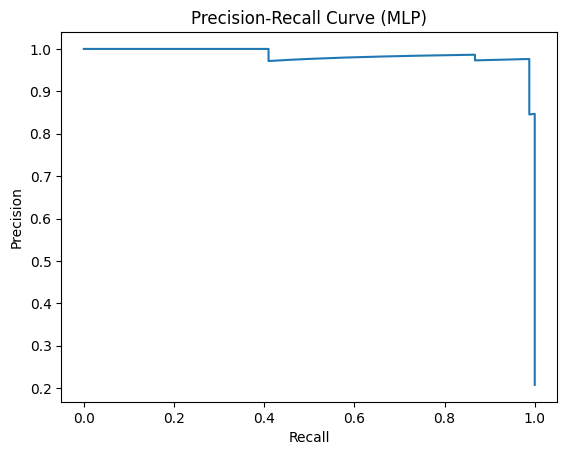

In [ ]:
b_offsets = torch.linspace(-10, 25, 2000)

precisions = []
recalls = []

for offset in b_offsets:
    prec, rec = precision_recall_at_bias_offset(net_1, offset.item(), X_val, Y_val)
    precisions.append(prec)
    recalls.append(rec)

plt.figure()
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (MLP)")
#plt.grid(True)
plt.savefig("Precision_recall_MLP.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
def metrics_at_bias(w, b_offset, X, Y):
    p = logreg_inference(w, b + b_offset, X)
    predictions = (p > 0.5).long()

    tp = ((predictions == 1) & (Y == 1)).sum().item()
    fp = ((predictions == 1) & (Y == 0)).sum().item()
    fn = ((predictions == 0) & (Y == 1)).sum().item()
    tn = ((predictions == 0) & (Y == 0)).sum().item()

    accuracy = (tp + tn) / len(Y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return accuracy, tp, fp, precision, recall


b_values = list(range(-11, 9))

print(f"{'b':>4} | {'Acc.':>7} | {'# T.P.':>7} | {'# F.P.':>7} | {'Prec.':>7} | {'Rec.':>7}")
print("-" * 55)

for b_offset in b_values:
    accuracy, tp, fp, precision, recall = metrics_at_bias(w, b_offset, X_val, Y_val)
    print(f"{b_offset:>4} | {accuracy*100:>6.1f}% | {tp:>7} | {fp:>7} | {precision*100:>6.1f}% | {recall*100:>6.1f}%")

   b |    Acc. |  # T.P. |  # F.P. |   Prec. |    Rec.
-------------------------------------------------------
 -11 |   79.2% |       0 |       0 |  100.0% |    0.0%
 -10 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -9 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -8 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -7 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -6 |   80.5% |       5 |       0 |  100.0% |    6.0%
  -5 |   82.5% |      13 |       0 |  100.0% |   15.7%
  -4 |   84.5% |      21 |       0 |  100.0% |   25.3%
  -3 |   88.0% |      36 |       1 |   97.3% |   43.4%
  -2 |   96.2% |      70 |       2 |   97.2% |   84.3%
  -1 |   98.5% |      79 |       2 |   97.5% |   95.2%
   0 |   99.2% |      82 |       2 |   97.6% |   98.8%
   1 |   98.5% |      82 |       5 |   94.3% |   98.8%
   2 |   96.0% |      82 |      15 |   84.5% |   98.8%
   3 |   93.0% |      83 |      28 |   74.8% |  100.0%
   4 |   91.0% |      83 |      36 |   69.7% |  100.0%
   5 |   

In [ ]:
def metrics_at_bias_offset(NET, b_offset, X, Y):
    original_bias = NET[-1].bias.data.clone()
    NET[-1].bias.data[1] += b_offset

    NET.eval()
    with torch.no_grad():
        logits = NET(X.to(DEVICE))
        predictions = torch.argmax(logits, dim=1)

    NET[-1].bias.data = original_bias

    Y = Y.to(DEVICE)
    tp = ((predictions == 1) & (Y == 1)).sum().item()
    fp = ((predictions == 1) & (Y == 0)).sum().item()
    fn = ((predictions == 0) & (Y == 1)).sum().item()
    tn = ((predictions == 0) & (Y == 0)).sum().item()

    accuracy = (tp + tn) / len(Y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    return accuracy, tp, fp, precision, recall


b_values = list(range(-11, 11))

print(f"{'b':>4} | {'Acc.':>7} | {'# T.P.':>7} | {'# F.P.':>7} | {'Prec.':>7} | {'Rec.':>7}")
print("-" * 55)

for b_offset in b_values:
    accuracy, tp, fp, precision, recall = metrics_at_bias_offset(net_1, b_offset, X_val, Y_val)
    print(f"{b_offset:>4} | {accuracy*100:>6.1f}% | {tp:>7} | {fp:>7} | {precision*100:>6.1f}% | {recall*100:>6.1f}%")

   b |    Acc. |  # T.P. |  # F.P. |   Prec. |    Rec.
-------------------------------------------------------
 -11 |   79.2% |       0 |       0 |  100.0% |    0.0%
 -10 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -9 |   79.2% |       0 |       0 |  100.0% |    0.0%
  -8 |   79.8% |       2 |       0 |  100.0% |    2.4%
  -7 |   82.0% |      11 |       0 |  100.0% |   13.3%
  -6 |   84.2% |      20 |       0 |  100.0% |   24.1%
  -5 |   84.8% |      22 |       0 |  100.0% |   26.5%
  -4 |   85.8% |      26 |       0 |  100.0% |   31.3%
  -3 |   91.5% |      50 |       1 |   98.0% |   60.2%
  -2 |   96.8% |      71 |       1 |   98.6% |   85.5%
  -1 |   98.2% |      78 |       2 |   97.5% |   94.0%
   0 |   99.0% |      82 |       3 |   96.5% |   98.8%
   1 |   99.0% |      82 |       3 |   96.5% |   98.8%
   2 |   99.0% |      82 |       3 |   96.5% |   98.8%
   3 |   97.0% |      82 |      11 |   88.2% |   98.8%
   4 |   94.2% |      83 |      23 |   78.3% |  100.0%
   5 |   